# Импорты библиотек

In [26]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator
import itertools
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests
import seaborn as sns

# Чтение данных

In [27]:
# Для отображения чисел не в экспоненциальном виде, а обрезанными до двух знаков после запятой
pd.options.display.float_format = '{:.2f}'.format

In [28]:
project_dir = Path.cwd().parent
data_path = project_dir / 'data' / 'marketplace.csv'
df = pd.read_csv(data_path)
display(df.head())

,user_id,platform_num,first_login,reg_dt,browser,first_buy,target,total_buy,total_return
0,user_000000,12,2025-03-22,2024-08-17,browser_00,2025-03-22,0.00,85.33,0.00
1,user_000001,1,2025-05-05,2025-05-15,browser_01,2025-05-20,0.00,21.82,0.00
2,user_000002,5,2025-01-19,2025-01-23,browser_02,2025-02-20,0.30,194.61,485.00
3,user_000003,3,2025-03-15,2023-09-05,browser_02,NaN,0.00,138.78,0.00
4,user_000004,1,2025-05-05,2025-05-14,browser_00,2025-05-11,0.00,16.33,0.00


In [29]:
#Приведение дат к datetime
date_cols = ["first_login", "reg_dt", "first_buy"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25335 entries, 0 to 25334
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       25335 non-null  object        
 1   platform_num  25335 non-null  int64         
 2   first_login   25335 non-null  datetime64[ns]
 3   reg_dt        25331 non-null  datetime64[ns]
 4   browser       25335 non-null  object        
 5   first_buy     24361 non-null  datetime64[ns]
 6   target        25335 non-null  float64       
 7   total_buy     25335 non-null  float64       
 8   total_return  25335 non-null  float64       
dtypes: datetime64[ns](3), float64(3), int64(1), object(2)
memory usage: 1.7+ MB


# Очистка данных

In [30]:
rows_before = df.shape[0]

df_sorted = df.sort_values(["user_id", "first_login"])

df_clean = (
    df_sorted
    .drop_duplicates(subset="user_id", keep="last")
    .reset_index(drop=True)
)

df = df_clean.copy()
rows_after = df.shape[0]

print(f"Строк до очистки:                     {rows_before}")
print(f"Строк после очистки:                  {rows_after}")
print(f"Удалено строк:                        {rows_before - rows_after}")
print(f"user_id уникальны после очистки:      {df_clean['user_id'].is_unique}")

Строк до очистки:                     25335
Строк после очистки:                  25331
Удалено строк:                        4
user_id уникальны после очистки:      True


# Гипотеза 6

Изучим, как ведут себя “старые” и “новые” клиенты:
- есть ли разница в возвратах между теми, кто давно покупает на маркетплейсе,
- и теми, кто сделал первую покупку недавно (или вообще ещё не покупал).
В датасете нет явной даты среза, но есть дата первой покупки `first_buy`. Для всех пользователей, попавших в выборку на дату среза, чем раньше `first_buy`, тем старше клиент, поэтому можно использовать дату первой покупки как приближённую меру “возраста клиента”.


Вероятность возврата в ближайший месяц зависит от «возраста» клиента:
- существует различие в доле возвратов между когортами по дате первой покупки (`first_buy`).

Отдельно выделяем пользователей без первой покупки (у кого `first_buy` отсутствует) как отдельную когорту.


**Стратегия проверки гипотезы**

1. Уберём смещение 0.3 из `target`

2. Разделяем пользователей на клиентские когорты по дате первой покупки:
- «Нет покупок» — first_buy отсутствует (NaT).
- Старые клиенты (Q1) — first_buy ≤ 25-й перцентиль (самые ранние даты).
- Ранние клиенты (Q2) — между 25-м и 50-м перцентилями.
- Средние клиенты (Q3) — между 50-м и 75-м перцентилями.
- Новые клиенты (Q4) — first_buy > 75-го перцентиля (самые поздние даты).

3. Для каждой когорты считаем:
- количество пользователей;
- долю пользователей с `has_return_next = (target > 0).astype(int)` (есть возвраты в ближайший месяц);
- среднее значение target.

4. Визуализируем:
- таблицу с метриками по когортам;
- столбчатую диаграмму: «когорта по дате первой покупки → доля пользователей с `has_return_next`».

=== Гипотеза 6. Дата первой покупки и вероятность возврата в следующий месяц ===

Границы квартилей по first_buy:
Q1 (25%): 2025-02-10
Q2 (50%): 2025-03-25
Q3 (75%): 2025-05-01

--- Возвраты в ближайший месяц по когортам (first_buy) ---


,Когорта по дате первой покупки,Количество пользователей,"Доля пользователей с возвратами, %",Среднее значение target
0,Нет покупок,973,94.35,0.31
1,Старые клиенты (Q1),6111,92.01,0.29
2,Ранние клиенты (Q2),6247,94.27,0.30
3,Средние клиенты (Q3),5995,92.49,0.30
4,Новые клиенты (Q4),6005,91.39,0.30


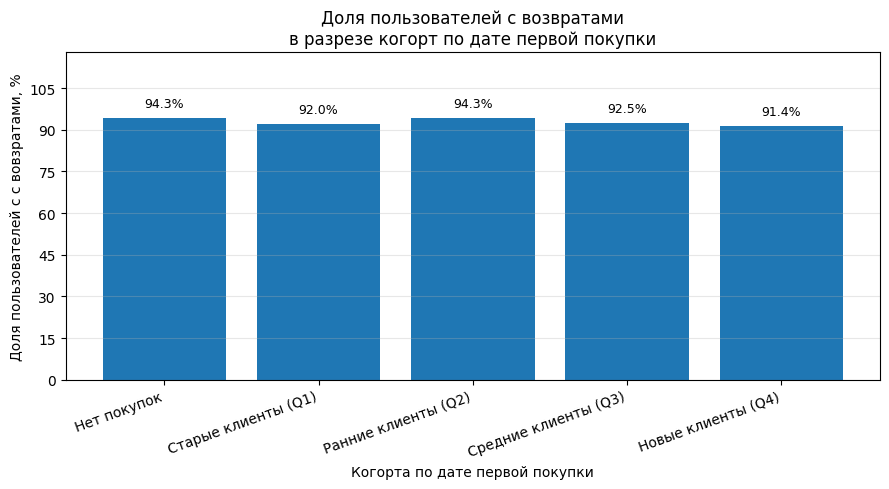


--- Сильные возвраты (target > 0.3) по когортам ---


,Когорта по дате первой покупки,Количество пользователей,Среднее значение target,"Доля пользователей с возвратами, %"
0,Нет покупок,12,2.49,1.23
1,Старые клиенты (Q1),87,1.66,1.42
2,Ранние клиенты (Q2),77,1.63,1.23
3,Средние клиенты (Q3),81,1.83,1.35
4,Новые клиенты (Q4),95,1.93,1.58


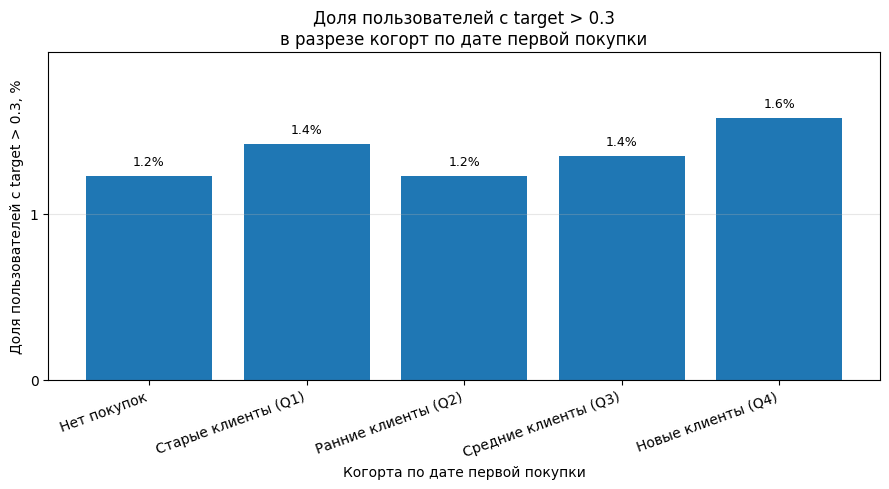

In [31]:
print("=== Гипотеза 6. Дата первой покупки и вероятность возврата в следующий месяц ===")

# Разбиваем исходный датасет на когорты по квантилям дат
df_h6 = df.copy()
df_h6["target"] = 0.3 - df_h6["target"]

q1 = df_h6["first_buy"].quantile(0.25)
q2 = df_h6["first_buy"].quantile(0.50)
q3 = df_h6["first_buy"].quantile(0.75)

print("\nГраницы квартилей по first_buy:")
print(f"Q1 (25%): {q1.date()}")
print(f"Q2 (50%): {q2.date()}")
print(f"Q3 (75%): {q3.date()}")

def first_buy_cohort(dt):
    if pd.isna(dt):
        return "Нет покупок"
    if dt <= q1:
        return "Старые клиенты (Q1)"
    if dt <= q2:
        return "Ранние клиенты (Q2)"
    if dt <= q3:
        return "Средние клиенты (Q3)"
    return "Новые клиенты (Q4)"

df_h6["first_buy_cohort"] = df_h6["first_buy"].map(first_buy_cohort)

cohort_order = [
    "Нет покупок",
    "Старые клиенты (Q1)",
    "Ранние клиенты (Q2)",
    "Средние клиенты (Q3)",
    "Новые клиенты (Q4)"
]

# Присваиваем бинарный признак: есть\нет возвраты в следующем месяце
df_h6["has_return_next"] = (df_h6["target"] > 0).astype(int)

# Выводим статистики по бинарному признаку
cohort_stats = (
    df_h6
    .groupby("first_buy_cohort", observed=False)
    .agg(
        users=("user_id", "count"),
        share_target_pos=("has_return_next", "mean"),
        mean_target=("target", "mean")
    )
    .reindex(cohort_order)
    .reset_index()
)

cohort_stats["share_target_pos"] = (cohort_stats["share_target_pos"] * 100).round(2)
cohort_stats["mean_target"] = cohort_stats["mean_target"].round(4)

cohort_stats_display = cohort_stats.rename(columns={
    "first_buy_cohort": "Когорта по дате первой покупки",
    "users": "Количество пользователей",
    "share_target_pos": "Доля пользователей с возвратами, %",
    "mean_target": "Среднее значение target"
})

print("\n--- Возвраты в ближайший месяц по когортам (first_buy) ---")
display(cohort_stats_display)

# Построение графика с долями пользователей с возвратами по возрастным когортам
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    cohort_stats_display["Когорта по дате первой покупки"],
    cohort_stats_display["Доля пользователей с возвратами, %"]
)

ax.set_title("Доля пользователей с возвратами\nв разрезе когорт по дате первой покупки")
ax.set_xlabel("Когорта по дате первой покупки")
ax.set_ylabel("Доля пользователей с с вовзратами, %")
ax.grid(axis="y", alpha=0.3)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

max_share = cohort_stats_display["Доля пользователей с возвратами, %"].max()
ax.set_ylim(0, max_share * 1.25)

plt.setp(ax.get_xticklabels(), rotation=20, ha="right")

for bar, val in zip(bars, cohort_stats_display["Доля пользователей с возвратами, %"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + max_share * 0.03,
        f"{val:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

print("\n--- Сильные возвраты (target > 0.3) по когортам ---")
# Выделяем датафрейм для подгруппы с высокими возвратами
df_h6_high = df_h6[df_h6["target"] > 0.30].copy()

# Рассчитываем статистики для когорты с высокими возвратами
cohort_stats_high = (
    df_h6_high
    .groupby("first_buy_cohort", observed=False)
    .agg(
        users=("user_id", "count"),
        mean_target=("target", "mean")
    )
    .reindex(cohort_order)
    .reset_index()
)

total_users = df_h6.groupby("first_buy_cohort")["user_id"].count().reindex(cohort_order).values
cohort_stats_high["share_return"] = (cohort_stats_high["users"] / total_users * 100).round(2)
cohort_stats_high["mean_target"] = cohort_stats_high["mean_target"].round(4)

cohort_stats_high_display = cohort_stats_high.rename(columns={
    "first_buy_cohort": "Когорта по дате первой покупки",
    "users": "Количество пользователей",
    "share_return": "Доля пользователей с возвратами, %",
    "mean_target": "Среднее значение target"
})

display(cohort_stats_high_display)

# Построение графика распределения долей покупателей с высокими возвратами по возрастным когортам
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    cohort_stats_high["first_buy_cohort"],
    cohort_stats_high["share_return"]
)
ax.set_title("Доля пользователей с target > 0.3\nв разрезе когорт по дате первой покупки")
ax.set_xlabel("Когорта по дате первой покупки")
ax.set_ylabel("Доля пользователей с target > 0.3, %")
ax.grid(axis="y", alpha=0.3)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
max_share = cohort_stats_high["share_return"].max()
ax.set_ylim(0, max_share * 1.25)
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
for bar, val in zip(bars, cohort_stats_high["share_return"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + max_share * 0.03,
        f"{val:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )
plt.tight_layout()
plt.show()

# Выводы по гипотезе 6

1. **Общая доля пользователей с возвратами (`target > 0`)**  
   - Наибольшая доля возвратов у клиентов без покупок (94.35%) и ранних клиентов (Q2 — 94.27%).  
   - Наименьшая доля возвратов у новых клиентов (Q4 — 91.39%) и старых клиентов (Q1 — 92.01%).  
   - Среднее значение `target` колеблется между 0.294 и 0.31, что указывает на умеренные различия между когортами.

2. **Сильные возвраты (`target > 0.3`)**  
   - Абсолютное количество клиентов с сильными возвратами невелико (от 12 до 95 человек на когорту, доля от 1.23% до 1.58%).  
   - Наибольшая доля сильных возвратов у новых клиентов (Q4 — 1.58%).  
   - Среднее значение `target` среди этих пользователей самое высокое у новых клиентов (1.9268) и без покупок (2.4905 — небольшая группа, поэтому не интерпретируется для всей когорты).

3. **Тенденции по «возрасту» клиента**  
   - Различия по когортам умеренные.  
   - «Краевые» когорты (новые клиенты Q4 и старые клиенты Q1) демонстрируют немного более высокие средние значения `target` среди сильных возвратов.  
   - Клиенты среднего «возраста» (Q2 и Q3) выглядят относительно стабильными по показателю возвратов.

4. **Практическая интерпретация**  
   - Возраст клиента по дате первой покупки можно учитывать как дополнительный фактор сегментации:  
     - Новые и старые клиенты могут требовать отдельного подхода для снижения возвратов или стимулирования повторных покупок.  
   - Эффект умеренный; доля «сильных возвратов» крайне мала, поэтому влияние на общую стратегию ограничено.


# Гипотеза 7. Влияние исторического коэффициента возвратов на поведение клиентов

**Идея гипотезы:**  
Изучим, как распределяются клиенты по историческому коэффициенту возвратов (`hist_return_rate`) в зависимости от «возраста» клиента, приближённо измеряемого через дату первой покупки (`first_buy`).  

- Есть ли различия по когортам: старые, средние, новые клиенты, а также клиенты без покупок?  
- Какие возрастные группы чаще попадают в бакеты с высокими историческими возвратами?  

**Стратегия проверки гипотезы:**

1. Рассчитываем исторический коэффициент возвратов:  
   - `hist_return_rate = total_return / total_buy` для клиентов с покупками и возвратами.  
   - Клиенты без покупок и с нулевыми возвратами формируют отдельные категории.

2. Формируем бакеты по историческим возвратам:  
   - «нет покупок», «0% возвратов», «0–10%», «10–50%», «50–100%», «100–500%», «>500%».

3. Для каждой когорты по `first_buy` строим распределение пользователей по бакетам исторических возвратов:  
   - Считаем количество пользователей в каждом бакете.  
   - Рассчитываем долю пользователей в процентах относительно когорты.

4. Визуализируем:  
   - Таблицу распределения по когорте и бакету исторических возвратов.  
   - Строим столбчатые диаграммы для наглядного сравнения когорт.



--- Описательные статистики hist_return_rate (там, где он посчитан) ---


,count,mean,std,min,25%,50%,75%,max
hist_return_rate,5399.00,13.71,525.72,0.00,0.36,0.66,1.57,38227.85



--- Распределение пользователей по корзинам исторических возвратов: ---


,Корзина по историческому коэффициенту возвратов,Количество пользователей
0,нет покупок,814
1,только возвраты,152
2,0% возвратов,19118
3,0–10%,170
4,10–50%,1885
5,50–100%,1365
6,100–500%,1466
7,>500%,361



--- Распределение пользователей по корзинам исторических возвратов и возрасту: ---


hist_return_bucket,нет покупок,только возвраты,0% возвратов,0–10%,10–50%,50–100%,100–500%,>500%
first_buy_cohort,,,,,,,,
Нет даты первой покупки,30,1,757,3,57,64,55,6
Старые клиенты (Q1),165,71,3970,55,730,514,477,129
Ранние клиенты (Q2),216,54,4613,52,439,323,432,118
Средние клиенты (Q3),188,16,4630,40,457,297,306,61
Новые клиенты (Q4),215,10,5148,20,202,167,196,47



--- Распределение пользователей по корзинам исторических возвратов и возрасту в процентах: ---


hist_return_bucket,Размер когорты,нет покупок,только возвраты,0% возвратов,0–10%,10–50%,50–100%,100–500%,>500%
first_buy_cohort,,,,,,,,,
Нет даты первой покупки,973,3.08%,0.10%,77.80%,0.31%,5.86%,6.58%,5.65%,0.62%
Старые клиенты (Q1),6111,2.70%,1.16%,64.96%,0.90%,11.95%,8.41%,7.81%,2.11%
Ранние клиенты (Q2),6247,3.46%,0.86%,73.84%,0.83%,7.03%,5.17%,6.92%,1.89%
Средние клиенты (Q3),5995,3.14%,0.27%,77.23%,0.67%,7.62%,4.95%,5.10%,1.02%
Новые клиенты (Q4),6005,3.58%,0.17%,85.73%,0.33%,3.36%,2.78%,3.26%,0.78%


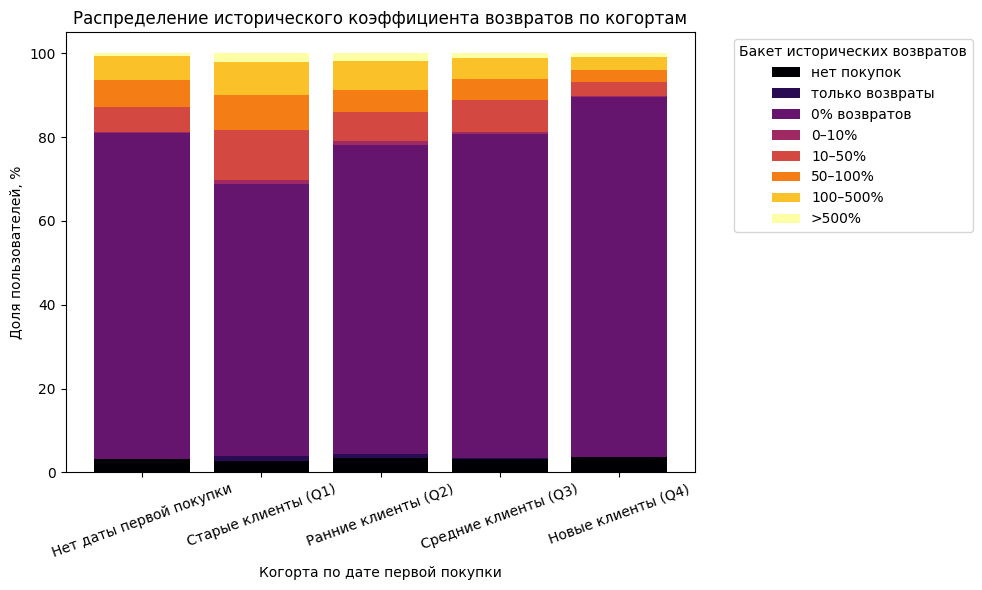

In [32]:
# Строим исторический коэффициент возвратов
df_h7 = df.copy()
mask_no_buy_no_ret  = (df_h7["total_buy"] == 0) & (df_h7["total_return"] == 0)
mask_no_buy_ret     = (df_h7["total_buy"] == 0) & (df_h7["total_return"] > 0)
mask_zero_ret    = (df_h7["total_buy"] > 0) & (df_h7["total_return"] == 0)
mask_nonzero_ret = (df_h7["total_buy"] > 0) & (df_h7["total_return"] > 0)

df_h7["hist_return_rate"] = np.nan
df_h7.loc[mask_nonzero_ret, "hist_return_rate"] = (
    df_h7.loc[mask_nonzero_ret, "total_return"] /
    df_h7.loc[mask_nonzero_ret, "total_buy"]
)
df_h7.loc[mask_no_buy_ret, "hist_return_rate"] = df_h7.loc[mask_no_buy_ret, "total_return"] 

print("\n--- Описательные статистики hist_return_rate (там, где он посчитан) ---")
display(df_h7["hist_return_rate"].describe().to_frame().T)

# Формируем корзины по историческим возвратам

# порядок корзин, который будем использовать везде
bucket_order = [
    "нет покупок",
    "только возвраты",
    "0% возвратов",
    "0–10%",
    "10–50%",
    "50–100%",
    "100–500%",
    ">500%"
]

df_h7["hist_return_bucket"] = None

df_h7.loc[mask_no_buy_no_ret,  "hist_return_bucket"] = "нет покупок"
df_h7.loc[mask_no_buy_ret,    "hist_return_bucket"] = "только возвраты"
df_h7.loc[mask_zero_ret, "hist_return_bucket"] = "0% возвратов"

bins   = [0, 0.1, 0.5, 1, 5, np.inf]
labels = ["0–10%", "10–50%", "50–100%", "100–500%", ">500%"]

bucket_series = pd.cut(
    df_h7.loc[mask_nonzero_ret, "hist_return_rate"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df_h7.loc[mask_nonzero_ret, "hist_return_bucket"] = bucket_series

# Распределение пользователей по корзинам

print("\n--- Распределение пользователей по корзинам исторических возвратов: ---")

vc = (
    df_h7["hist_return_bucket"]
    .value_counts()
    .reindex(bucket_order)
    .rename_axis("Корзина по историческому коэффициенту возвратов")
    .reset_index(name="Количество пользователей")
)

display(vc)

# Добавляем когортный признак по возрасту клиента
q1 = df_h7["first_buy"].quantile(0.25)
q2 = df_h7["first_buy"].quantile(0.50)
q3 = df_h7["first_buy"].quantile(0.75)

def first_buy_cohort(dt):
    if pd.isna(dt):
        return "Нет даты первой покупки"
    if dt <= q1:
        return "Старые клиенты (Q1)"
    if dt <= q2:
        return "Ранние клиенты (Q2)"
    if dt <= q3:
        return "Средние клиенты (Q3)"
    return "Новые клиенты (Q4)"

df_h7["first_buy_cohort"] = df_h7["first_buy"].map(first_buy_cohort)
print("\n--- Распределение пользователей по корзинам исторических возвратов и возрасту: ---")
cohort_vs_hist_bucket = (
    df_h7
    .pivot_table(
        index="first_buy_cohort",
        columns="hist_return_bucket",
        values="user_id",
        aggfunc="count",
        fill_value=0
    )
    .reindex(index=[
        "Нет даты первой покупки",
        "Старые клиенты (Q1)",
        "Ранние клиенты (Q2)",
        "Средние клиенты (Q3)",
        "Новые клиенты (Q4)"
    ])
    .reindex(columns=bucket_order)
)

display(cohort_vs_hist_bucket)

# Перевод в доли внутри когорты
cohort_vs_hist_bucket_pct = cohort_vs_hist_bucket.div(cohort_vs_hist_bucket.sum(axis=1), axis=0) * 100

print("\n--- Распределение пользователей по корзинам исторических возвратов и возрасту в процентах: ---")
# Выводим таблицу с долями в процентах пользователей по корзинам исторических возвратов и возрасту
df_with_percents = cohort_vs_hist_bucket_pct.copy()
df_with_percents["Размер когорты"] = cohort_vs_hist_bucket.sum(axis=1)
cols = ["Размер когорты"] + bucket_order
df_with_percents = df_with_percents[cols]
def fmt(x):
    return f"{x:.2f}%"
for col in bucket_order:
    df_with_percents[col] = df_with_percents[col].apply(fmt)
display(df_with_percents)

# Построение stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))

bottom = np.zeros(len(cohort_vs_hist_bucket_pct))
colors = plt.cm.inferno(np.linspace(0, 1, len(bucket_order)))

for idx, bucket in enumerate(bucket_order):
    values = cohort_vs_hist_bucket_pct[bucket].values
    ax.bar(
        cohort_vs_hist_bucket_pct.index,
        values,
        bottom=bottom,
        label=bucket,
        color=colors[idx]
    )
    bottom += values

ax.set_ylabel("Доля пользователей, %")
ax.set_xlabel("Когорта по дате первой покупки")
ax.set_title("Распределение исторического коэффициента возвратов по когортам")
ax.legend(title="Бакет исторических возвратов", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Вывод по гипотезе 7. Влияние исторического коэффициента возвратов на поведение клиентов

Наблюдаются различия в распределении исторического коэффициента возвратов между когортами по дате первой покупки.


Анализ распределения бакетов исторического коэффициента возвратов по когортам (разбивка по дате первой покупки) показывает ряд устойчивых и важных закономерностей:

### 1. Доля клиентов без возвратов растёт от старых когорт к новым
- **Старые клиенты (Q1):** 64.96% без возвратов  
- **Новые клиенты (Q4):** 85.73% без возвратов  

Новые клиенты выглядят более «здоровой» аудиторией по возвратам.

### 2. Старые клиенты чаще демонстрируют высокий уровень возвратов
Бакеты с высоким return rate (50–100%, 100–500%, >500%) особенно характерны для Q1:

- **Q1 → “100–500%”:** 7.81%  
- **Q1 → “>500%”:** 2.11%  
- В новых когорт таких клиентов заметно меньше: например, в Q4 → “>500%” всего 0.78%.

Это указывает на то, что именно старые клиенты создают наибольшую финансовую нагрузку: они чаще возвращают товар и при этом продолжают покупать.

### 3. Доля пользователей только с возвратами крайне мала
- В старых когортных группах: **1.16% → 0.27%** по мере перехода к Q3  
- В новых: всего **0.17%**

Такая группа действительно существует, но не является массовой.

### 4. “Нет покупок” распределены равномерно и дают 2.7–3.6%
Это пользователи, которые зарегистрировались, но так ничего и не купили.  
На них не влияют проблемы возвратов, но они важны при анализе качества трафика и воронки.

### 5. Основная зона риска — когорты Q1 и частично Q2
У этих клиентов заметно выше доля всех “плохих” бакетов:
- 10–50%
- 50–100%
- 100–500%
- \>500%

### 6. Новые клиенты имеют отличную обратную связь для прогноза LTV
Высокая доля «0% возвратов» + низкие доли плохих бакетов означают:
- минимальный возвратный риск,  
- высокая маржинальность,  
- меньше будущих возвратных расходов.

---

### Основной вывод
**Исторический уровень возвратов различается между когортами: старые клиенты дают больше проблемных возвратов, тогда как новые клиенты — наиболее качественная и прибыльная аудитория.**  

Это означает, что:
- при прогнозировании LTV когортность по дате первой покупки обязательна;  
- маркетинговые усилия стоит смещать в сторону сегментов с профилем возвратов, похожим на Q3–Q4;  
- с когорой Q1 нужно проработать отдельные гипотезы: перерасчёт условий, антифрод, ограничение частоты заказов, пересмотр ассортимента или коммуникаций.

In [33]:
print("=== Вывод средних и медианных исторических возвратов и покупок по возрастным когортам ===")

df_h7_1 = df_h7.copy()

cohort_order = [
    "Нет даты первой покупки",
    "Старые клиенты (Q1)",
    "Ранние клиенты (Q2)",
    "Средние клиенты (Q3)",
    "Новые клиенты (Q4)"
]

cohort_mean_stats = (
    df_h7_1
    .groupby("first_buy_cohort", observed=False)
    .agg(
        users=("user_id", "count"),
        mean_total_return=("total_return", "mean"),
        mean_total_buy=("total_buy", "mean")
    )
    .reindex(cohort_order)
    .reset_index()
)

cohort_mean_stats_display = cohort_mean_stats.rename(columns={
    "first_buy_cohort": "Когорта по дате первой покупки",
    "users": "Количество пользователей",
    "mean_total_return": "Среднее историческое значение возвратов",
    "mean_total_buy": "Среднее историческое значение покупок"
})

display(cohort_mean_stats_display)


cohort_median_stats = (
    df_h7_1
    .groupby("first_buy_cohort", observed=False)
    .agg(
        users=("user_id", "count"),
        median_total_return=("total_return", "median"),
        median_total_buy=("total_buy", "median")
    )
    .reindex(cohort_order)
    .reset_index()
)

cohort_median_stats_display = cohort_median_stats.rename(columns={
    "first_buy_cohort": "Когорта по дате первой покупки",
    "users": "Количество пользователей",
    "median_total_return": "Медианное историческое значение возвратов",
    "median_total_buy": "Медианное историческое значение покупок"
})

display(cohort_median_stats_display)

=== Вывод средних и медианных исторических возвратов и покупок по возрастным когортам ===


,Когорта по дате первой покупки,Количество пользователей,Среднее историческое значение возвратов,Среднее историческое значение покупок
0,Нет даты первой покупки,973,464.26,1077.00
1,Старые клиенты (Q1),6111,539.61,1261.78
2,Ранние клиенты (Q2),6247,347.69,926.15
3,Средние клиенты (Q3),5995,349.42,1089.40
4,Новые клиенты (Q4),6005,67.46,277.45


,Когорта по дате первой покупки,Количество пользователей,Медианное историческое значение возвратов,Медианное историческое значение покупок
0,Нет даты первой покупки,973,0.00,75.66
1,Старые клиенты (Q1),6111,0.00,75.03
2,Ранние клиенты (Q2),6247,0.00,48.05
3,Средние клиенты (Q3),5995,0.00,58.17
4,Новые клиенты (Q4),6005,0.00,38.66


# Статистические проверки гипотезы 7

**Гипотеза 7:**  
Вероятность возврата зависит от возраста клиента (когорты по дате первой покупки). Старые клиенты совершают больше возвратов в историческом разрезе, чем новые клиенты.  

**Цель анализа:**  
Определить, какая возрастная когорта является статистически более «проблемной» с точки зрения возвратов, используя **исторические бакеты возвратов** (например, 50–100%, 100–500% и т.д.).  

**Подход:**  

1. Разделяем пользователей на возрастные когорты по дате первой покупки:  
   - Нет даты первой покупки  
   - Старые клиенты (Q1)  
   - Ранние клиенты (Q2)  
   - Средние клиенты (Q3)  
   - Новые клиенты (Q4)  

2. Для каждой возрастной когорты считаем количество пользователей в каждом **бакете исторических возвратов**:  
   - Нет покупок, только возвраты, 0%, 0–10%, 10–50%, 50–100%, 100–500%, >500%  

3. Для каждой «проблемной» категории (например, 50–100%, 100–500%) проводим **z-тест для долей** по каждой паре когорт, чтобы определить, какая из когорт статистически значимо отличается по доле проблемных пользователей.  

4. Для коррекции на множественные сравнения используем метод **Бонферрони**, чтобы контролировать вероятность ложноположительных результатов.  

**Вывод:**  
Эксперимент позволяет сразу определить **направление различий** (в какой когортe больше пользователей с высокими историческими возвратами) и проверить их **статистическую значимость**.

=== Z-тест по частоте попадания возрастных групп в бакеты с повышенными историческими возвратами ===


,Корзина,Когорта 1,Когорта 2,Доля Когорта 1,Доля Когорта 2,p-value (скорректированное),Статистически значимо?,Чаще попадает в бакет
0,10–50%,Нет даты первой покупки,Старые клиенты (Q1),5.860000,11.950000,0.000000,Да,Старые клиенты (Q1)
1,10–50%,Нет даты первой покупки,Ранние клиенты (Q2),5.860000,7.030000,1.000000,Нет,Ранние клиенты (Q2)
2,10–50%,Нет даты первой покупки,Средние клиенты (Q3),5.860000,7.620000,0.507600,Нет,Средние клиенты (Q3)
3,10–50%,Нет даты первой покупки,Новые клиенты (Q4),5.860000,3.360000,0.001300,Да,Нет даты первой покупки
4,10–50%,Старые клиенты (Q1),Ранние клиенты (Q2),11.950000,7.030000,0.000000,Да,Старые клиенты (Q1)
5,10–50%,Старые клиенты (Q1),Средние клиенты (Q3),11.950000,7.620000,0.000000,Да,Старые клиенты (Q1)
6,10–50%,Старые клиенты (Q1),Новые клиенты (Q4),11.950000,3.360000,0.000000,Да,Старые клиенты (Q1)
7,10–50%,Ранние клиенты (Q2),Средние клиенты (Q3),7.030000,7.620000,1.000000,Нет,Средние клиенты (Q3)
8,10–50%,Ранние клиенты (Q2),Новые клиенты (Q4),7.030000,3.360000,0.000000,Да,Ранние клиенты (Q2)
9,10–50%,Средние клиенты (Q3),Новые клиенты (Q4),7.620000,3.360000,0.000000,Да,Средние клиенты (Q3)


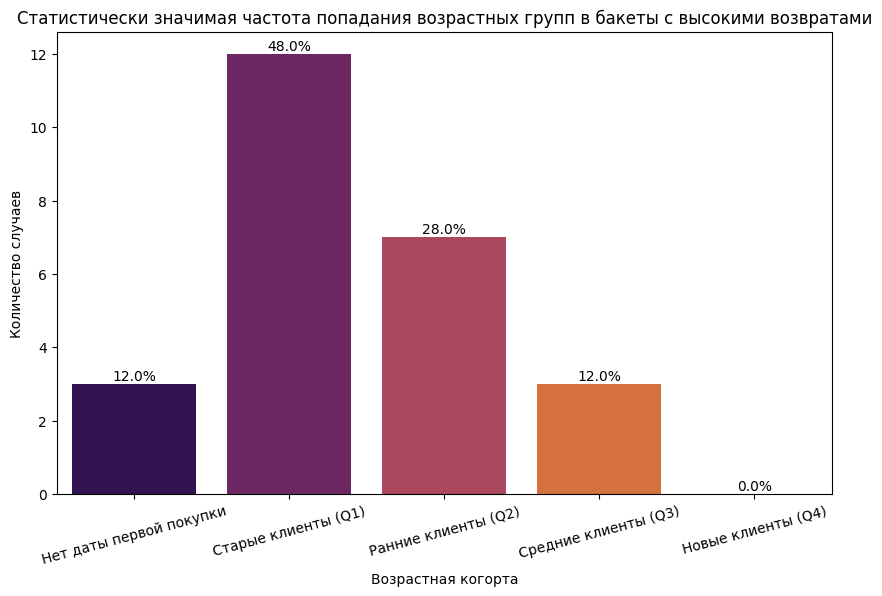

In [34]:
print("=== Z-тест по частоте попадания возрастных групп в бакеты с повышенными историческими возвратами ===")

df_z_test = df_h7.copy()

bucket_order = [
    "10–50%",
    "50–100%",
    "100–500%",
    ">500%"
]

cohort_order = [
    "Нет даты первой покупки",
    "Старые клиенты (Q1)",
    "Ранние клиенты (Q2)",
    "Средние клиенты (Q3)",
    "Новые клиенты (Q4)"
]

results = []

# Для каждой корзины возвратов по всем комбинациям возрастных пар проводим z-test
for bucket in bucket_order:
    df_z_test[f'in_bucket_{bucket}'] = (df_z_test['hist_return_bucket'] == bucket).astype(int)
    pairs = list(itertools.combinations(cohort_order, 2))
    p_values = []
    pair_list = []
    counts_dict = {}
    
    for c1, c2 in pairs:
        subset = df_z_test[df_z_test['first_buy_cohort'].isin([c1, c2])]
        counts = subset.groupby('first_buy_cohort')[f'in_bucket_{bucket}'].sum()
        nobs = subset.groupby('first_buy_cohort')[f'in_bucket_{bucket}'].count()
        
        proportion_c1 = counts[c1] / nobs[c1]
        proportion_c2 = counts[c2] / nobs[c2]
        counts_dict[(c1, c2)] = (proportion_c1, proportion_c2)
        
        stat, pval = proportions_ztest(counts.values, nobs.values)
        p_values.append(pval)
        pair_list.append((c1, c2))
    # Добавляем поправку Бонферони для множественных сравнений
    reject, pvals_corrected, _, _ = multipletests(p_values, method='bonferroni')
    #Выделяем возрастную когорту, которая чаще попадает в корзину
    for (c1, c2), p_corr, r in zip(pair_list, pvals_corrected, reject):
        prop1, prop2 = counts_dict[(c1, c2)]
        if prop1 > prop2:
            more_freq = c1
        elif prop2 > prop1:
            more_freq = c2
        else:
            more_freq = "равны"
        
        results.append({
            'Корзина': bucket,
            'Когорта 1': c1,
            'Когорта 2': c2,
            'Доля Когорта 1': round(prop1*100, 2),
            'Доля Когорта 2': round(prop2*100, 2),
            'p-value (скорректированное)': round(p_corr, 4),
            'Статистически значимо?': 'Да' if r else 'Нет',
            'Чаще попадает в бакет': more_freq
        })

results_df = pd.DataFrame(results)
# Настраиваем датафрейм для вывода всех строк, окрашиваем значимые
pd.set_option('display.max_rows', None)
def highlight_significant(row):
    if row["Статистически значимо?"] == "Да":
        return ["background-color: #D9EDF7"] * len(row)  # голубой
    else:
        return [""] * len(row)

styled_df = results_df.style.apply(highlight_significant, axis=1)
display(styled_df)

# Строим график распределения когорт по статистически значимым попаданиям в проблемную корзину возвратов
sig_df = results_df[results_df["Статистически значимо?"] == "Да"]
freq_df = sig_df['Чаще попадает в бакет'].value_counts().reindex(cohort_order, fill_value=0)
freq_df = freq_df.reset_index()
freq_df.columns = ['Когорта', 'Частота']

total = freq_df['Частота'].sum()
freq_df['Процент'] = freq_df['Частота'] / total * 100

plt.figure(figsize=(10,6))
ax = sns.barplot(
    x='Когорта',
    y='Частота',
    hue='Когорта',
    data=freq_df,
    palette='inferno',
    legend=False)

for i, row in freq_df.iterrows():
    ax.text(i, row['Частота'] + 0.1, f"{row['Процент']:.1f}%", ha='center')

ax.set_title('Статистически значимая частота попадания возрастных групп в бакеты с высокими возвратами')
ax.set_ylabel('Количество случаев')
ax.set_xlabel('Возрастная когорта')
plt.xticks(rotation=15)
plt.show()

## Выводы по статистическим проверкам гипотезы 7
- Наиболее проблемная когорта с точки зрения возвратов — **старые клиенты (Q1)**.  
- Ранние клиенты (Q2) и средние клиенты (Q3) занимают промежуточное положение.  
- Новые клиенты (Q4) практически не попадают в высокие бакеты возвратов.  
- Гипотеза о том, что доля пользователей с высокими историческими возвратами различается между когортами, **подтверждается**, и направление различий указано в колонке «Чаще попадает в бакет».


# Гипотеза 8
- Клиенты, которые не сразу начали покупать, совершают меньше покупок
- Клиенты, которые не сразу начали покупать, совершают больше возвратов
## Проврека гипотезы
1. Обработаем пропуски в `first_login`, `reg_dt`, `first_buy`

    1.1 Если не указана одна из `first_login` или `reg_dt`, то присваиваем известное значение даты в неизвестную.
    
    1.2 Если не указаны обе - `first_login`, `reg_dt`, считаем, что пропуск в дате означает, что дата меньше среза, тогда установим в пропусках `min(date) - days(1)`

    1.2 Если `first_buy` не указан, но при этом `total_buy` или `total_return` не нулевые, то тогда устанавливаем `first_buy` как `min(date) - days(1)`
2. Обработка аномалий дат `first_login`, `reg_dt`, `first_buy`

    2.2 Из двух дат `first_login` и `reg_dt` для оценки задержки берём ту, что меньше `first_buy`

    2.3 Если обе даты меньше `first_buy`, то выделяем в отдельную группу - исследование невозможно
3. Вычислим `delay_in_days` для каждой строчки df
4. Разобьём на когорты по значению `delay_in_days`: big_delay, normal_delay, no_delay
5. Посмотрим значения `target` и `history_return_ratio` в этих когортах
6. Проведём стат тест значимости различий в распределении при необходимости

=== Обработка пропусков в столбцах с датами ===


,first_login,reg_dt,first_buy
count,25331,25327,24358
mean,2025-03-13 23:15:02.025186816,2024-12-06 08:07:56.455955712,2025-03-11 14:14:29.628048384
min,2024-09-21 00:00:00,2022-10-11 00:00:00,2023-08-08 00:00:00
25%,2025-02-07 00:00:00,2024-10-12 00:00:00,2025-02-10 00:00:00
50%,2025-03-23 00:00:00,2025-02-17 00:00:00,2025-03-25 00:00:00
75%,2025-04-25 00:00:00,2025-04-18 00:00:00,2025-05-01 00:00:00
max,2025-07-26 00:00:00,2025-07-26 00:00:00,2025-07-25 00:00:00



Количество не указанных дат первого логина: 0
Количество не указанных дат регистрации: 4
Количество не указанных дат первой покупки: 973

=== Заполним пропуски в датах ===

Количество не указанных дат регистрации: 0
Количество не указанных дат первой покупки: 0

=== Вычислим задержку между регистрацией и покупками в днях ===

Количество строк в группе, которую невозможно проанализировать из-за аномалий в датах: 6538
Количество аномалий в процентах от выборки: 25.81%

=== Описание столбца с задержкой между регистрацией и покупками в днях ===


count   18793.00
mean      122.67
std       214.23
min         1.00
25%         5.00
50%        13.00
75%       135.00
max       999.00
Name: delay_days, dtype: float64


Границы квартилей по delay_days:
Q1 (25%): 5.0
Q2 (50%): 13.0
Q3 (75%): 135.0


...

,Когорта по задержке до даты первой покупки,Количество пользователей,Медианное историческое значение возвратов,Медианное историческое значение покупок
0,Невозможно исследовать,6538,0.00,47.37
1,Очень быстрая покупка (Q1),4982,0.00,45.15
2,Быстрая покупка (Q2),4765,0.00,42.84
3,Медленная покупка (Q3),4356,0.00,42.93
4,Очень медленная покупка (Q4),4690,0.00,140.84



--- Распределение пользователей по корзинам исторических возвратов и задержке в днях до первой покупки: ---


hist_return_bucket,нет покупок,только возвраты,0% возвратов,0–10%,10–50%,50–100%,100–500%,>500%
delay_days_cohort,,,,,,,,
Невозможно исследовать,210,47,4975,35,448,346,384,93
Очень быстрая покупка (Q1),145,30,3887,23,319,235,254,89
Быстрая покупка (Q2),174,44,3629,19,331,207,296,65
Медленная покупка (Q3),161,27,3398,18,250,202,225,75
Очень медленная покупка (Q4),124,4,3229,75,537,375,307,39



--- Распределение пользователей по корзинам исторических возвратов и задержке в днях до первой покупки в процентах: ---


hist_return_bucket,Размер когорты,нет покупок,только возвраты,0% возвратов,0–10%,10–50%,50–100%,100–500%,>500%
delay_days_cohort,,,,,,,,,
Невозможно исследовать,6538,3.21%,0.72%,76.09%,0.54%,6.85%,5.29%,5.87%,1.42%
Очень быстрая покупка (Q1),4982,2.91%,0.60%,78.02%,0.46%,6.40%,4.72%,5.10%,1.79%
Быстрая покупка (Q2),4765,3.65%,0.92%,76.16%,0.40%,6.95%,4.34%,6.21%,1.36%
Медленная покупка (Q3),4356,3.70%,0.62%,78.01%,0.41%,5.74%,4.64%,5.17%,1.72%
Очень медленная покупка (Q4),4690,2.64%,0.09%,68.85%,1.60%,11.45%,8.00%,6.55%,0.83%


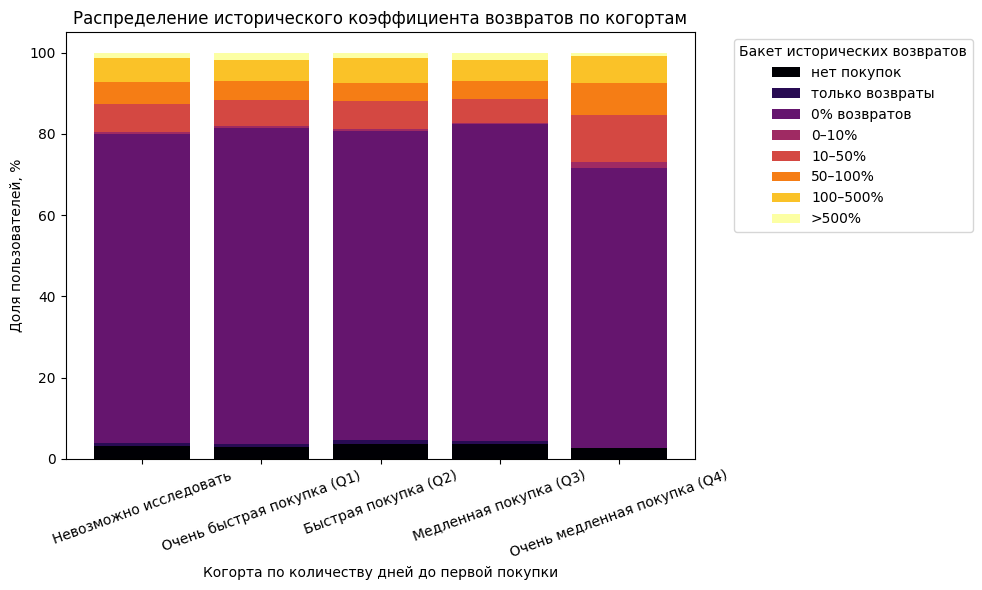

In [35]:
print("=== Обработка пропусков в столбцах с датами ===")
# Обработка пропусков в датах
df_h8 = df.copy()
display(df_h8[["first_login", "reg_dt", "first_buy"]].describe())
print(
    f"\nКоличество не указанных дат первого логина: {df_h8["first_login"].isna().sum()}"
    f"\nКоличество не указанных дат регистрации: {df_h8["reg_dt"].isna().sum()}"
    f"\nКоличество не указанных дат первой покупки: {df_h8["first_buy"].isna().sum()}"
)
print("\n=== Заполним пропуски в датах ===")
df_h8["reg_dt"] = df_h8["reg_dt"].fillna(df_h8["first_login"])
min_first_buy_date = df_h8["first_buy"].min() - pd.Timedelta(days=1)
df_h8["first_buy"] = df_h8["first_buy"].fillna(min_first_buy_date)
print(
    f"\nКоличество не указанных дат регистрации: {df_h8["reg_dt"].isna().sum()}"
    f"\nКоличество не указанных дат первой покупки: {df_h8["first_buy"].isna().sum()}"
)
print("\n=== Вычислим задержку между регистрацией и покупками в днях ===")
# Расчёт задержки между регистрацией и первой покупкой, обработка аномалий в данных
def calculate_days_delay(row):
    reg_dt = row["reg_dt"]
    first_login = row["first_login"]
    first_buy = row["first_buy"]
    if reg_dt < first_buy:
        return (first_buy - reg_dt).components.days
    elif first_login < first_buy:
        return (first_buy - first_login).components.days
    else:
        return np.nan
df_h8["delay_days"] = df_h8.apply(calculate_days_delay, axis = 1)
print(
    f"\nКоличество строк в группе, которую невозможно проанализировать из-за аномалий в датах: {df_h8["delay_days"].isna().sum()}"
    f"\nКоличество аномалий в процентах от выборки: {df_h8["delay_days"].isna().sum() / len(df_h8) * 100:.2f}%"
    )
print("\n=== Описание столбца с задержкой между регистрацией и покупками в днях ===")
# Выделение когорт по задержкам
display(df_h8["delay_days"][~df_h8["delay_days"].isna()].describe())

q1 = df_h8["delay_days"].quantile(0.25)
q2 = df_h8["delay_days"].quantile(0.50)
q3 = df_h8["delay_days"].quantile(0.75)

print("\nГраницы квартилей по delay_days:")
print(f"Q1 (25%): {q1}")
print(f"Q2 (50%): {q2}")
print(f"Q3 (75%): {q3}")


def delay_days_cohort(dt):
    if pd.isna(dt):
        return "Невозможно исследовать"
    if dt <= q1:
        return "Очень быстрая покупка (Q1)"
    if dt <= q2:
        return "Быстрая покупка (Q2)"
    if dt <= q3:
        return "Медленная покупка (Q3)"
    return "Очень медленная покупка (Q4)"

df_h8["delay_days_cohort"] = df_h8["delay_days"].map(delay_days_cohort)

cohort_order = [
    "Невозможно исследовать",
    "Очень быстрая покупка (Q1)",
    "Быстрая покупка (Q2)",
    "Медленная покупка (Q3)",
    "Очень медленная покупка (Q4)"
]

# Расчёт статистик по когортам задержек
cohort_mean_stats = (
    df_h8
    .groupby("delay_days_cohort", observed=False)
    .agg(
        users=("user_id", "count"),
        mean_total_return=("total_return", "mean"),
        mean_total_buy=("total_buy", "mean")
    )
    .reindex(cohort_order)
    .reset_index()
)

cohort_mean_stats_display = cohort_mean_stats.rename(columns={
    "delay_days_cohort": "Когорта задержке до даты первой покупки",
    "users": "Количество пользователей",
    "mean_total_return": "Среднее историческое значение возвратов",
    "mean_total_buy": "Среднее историческое значение покупок"
})

display(cohort_mean_stats_display)


cohort_median_stats = (
    df_h8
    .groupby("delay_days_cohort", observed=False)
    .agg(
        users=("user_id", "count"),
        median_total_return=("total_return", "median"),
        median_total_buy=("total_buy", "median")
    )
    .reindex(cohort_order)
    .reset_index()
)

cohort_median_stats_display = cohort_median_stats.rename(columns={
    "delay_days_cohort": "Когорта по задержке до даты первой покупки",
    "users": "Количество пользователей",
    "median_total_return": "Медианное историческое значение возвратов",
    "median_total_buy": "Медианное историческое значение покупок"
})

display(cohort_median_stats_display)

# Добавляем когорты по историческим возвратам
mask_no_buy_no_ret  = (df_h8["total_buy"] == 0) & (df_h8["total_return"] == 0)
mask_no_buy_ret     = (df_h8["total_buy"] == 0) & (df_h8["total_return"] > 0)
mask_zero_ret    = (df_h8["total_buy"] > 0) & (df_h8["total_return"] == 0)
mask_nonzero_ret = (df_h8["total_buy"] > 0) & (df_h8["total_return"] > 0)

df_h8["hist_return_rate"] = np.nan
df_h8.loc[mask_nonzero_ret, "hist_return_rate"] = (
    df_h8.loc[mask_nonzero_ret, "total_return"] /
    df_h8.loc[mask_nonzero_ret, "total_buy"]
)
df_h8.loc[mask_no_buy_ret, "hist_return_rate"] = df_h8.loc[mask_no_buy_ret, "total_return"] 
# порядок корзин, который будем использовать везде
bucket_order = [
    "нет покупок",
    "только возвраты",
    "0% возвратов",
    "0–10%",
    "10–50%",
    "50–100%",
    "100–500%",
    ">500%"
]

df_h8["hist_return_bucket"] = None

df_h8.loc[mask_no_buy_no_ret,  "hist_return_bucket"] = "нет покупок"
df_h8.loc[mask_no_buy_ret,    "hist_return_bucket"] = "только возвраты"
df_h8.loc[mask_zero_ret, "hist_return_bucket"] = "0% возвратов"

bins   = [0, 0.1, 0.5, 1, 5, np.inf]
labels = ["0–10%", "10–50%", "50–100%", "100–500%", ">500%"]

bucket_series = pd.cut(
    df_h8.loc[mask_nonzero_ret, "hist_return_rate"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df_h8.loc[mask_nonzero_ret, "hist_return_bucket"] = bucket_series

print("\n--- Распределение пользователей по корзинам исторических возвратов и задержке в днях до первой покупки: ---")
# Строим распределение пользователей из когорт задержек по корзинам возратов
cohort_vs_hist_bucket = (
    df_h8
    .pivot_table(
        index="delay_days_cohort",
        columns="hist_return_bucket",
        values="user_id",
        aggfunc="count",
        fill_value=0
    )
    .reindex(index=[
        "Невозможно исследовать",
        "Очень быстрая покупка (Q1)",
        "Быстрая покупка (Q2)",
        "Медленная покупка (Q3)",
        "Очень медленная покупка (Q4)"
    ])
    .reindex(columns=bucket_order)
)

display(cohort_vs_hist_bucket)

# Перевод в доли внутри когорты
cohort_vs_hist_bucket_pct = cohort_vs_hist_bucket.div(cohort_vs_hist_bucket.sum(axis=1), axis=0) * 100

print("\n--- Распределение пользователей по корзинам исторических возвратов и задержке в днях до первой покупки в процентах: ---")
df_with_percents = cohort_vs_hist_bucket_pct.copy()
df_with_percents["Размер когорты"] = cohort_vs_hist_bucket.sum(axis=1)
cols = ["Размер когорты"] + bucket_order
df_with_percents = df_with_percents[cols]
def fmt(x):
    return f"{x:.2f}%"
for col in bucket_order:
    df_with_percents[col] = df_with_percents[col].apply(fmt)
display(df_with_percents)

# Построение stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))

bottom = np.zeros(len(cohort_vs_hist_bucket_pct))
colors = plt.cm.inferno(np.linspace(0, 1, len(bucket_order)))

for idx, bucket in enumerate(bucket_order):
    values = cohort_vs_hist_bucket_pct[bucket].values
    ax.bar(
        cohort_vs_hist_bucket_pct.index,
        values,
        bottom=bottom,
        label=bucket,
        color=colors[idx]
    )
    bottom += values

ax.set_ylabel("Доля пользователей, %")
ax.set_xlabel("Когорта по количеству дней до первой покупки")
ax.set_title("Распределение исторического коэффициента возвратов по когортам")
ax.legend(title="Бакет исторических возвратов", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Выводы по распределению исторических возвратов в зависимости от задержки до первой покупки

#### 1. Поведение пользователей в когортax Q1–Q3 практически одинаково
Когорты  
*«Очень быстрая покупка (Q1)»*,  
*«Быстрая покупка (Q2)»*,  
*«Медленная покупка (Q3)»*  
демонстрируют близкую структуру возвратов:
- 75–78% пользователей имеют **0% возвратов**.
- 5–7% пользователей попадают в корзину **10–50% возвратов**.
- 4–5% — в корзину **50–100% возвратов**.
- 5–6% — в корзину **100–500% возвратов**.
- 1–1.7% — в корзину **>500% возвратов**.

Это означает, что пользователи, совершающие покупку в течение разумного времени после регистрации, имеют **стабильное и похожее паттерновое поведение**.

#### 2. Когорта «Очень медленная покупка (Q4)» заметно отличается
Для пользователей, у которых задержка между регистрацией и первой покупкой максимальная, наблюдается существенное изменение структуры возвратов:
- **0% возвратов** — только **68.85%** (ниже других когорт).
- Значительно выше доля проблемных корзин:
  - **10–50%** — 11.45%.
  - **50–100%** — 8.00%.
  - **100–500%** — 6.55%.

Таким образом, слишком длительная задержка до первой покупки **ассоциирована с повышенным риском возвратов** и более нестабильным поведением.

#### 3. Когорта «Невозможно исследовать» похожа на Q1–Q3
Несмотря на аномалии в датах, структура возвратов у этой когорты сопоставима с Q1–Q3. Это указывает на то, что проблемы с датами, вероятно, носят технический характер и **не отражают отличий в поведении**.

#### 4. Эффект не линейный: ухудшение поведения наблюдается только в Q4
Между Q1, Q2 и Q3 различия минимальны.  
Резкое ухудшение поведения фиксируется **только в когорте Q4**, что говорит о существовании порогового значения задержки.

#### 5. Интерпретация
- Q1–Q3 — это **нормальные и предсказуемые пользователи**.
- Q4 — это **потенциально сложная группа**, характеризующаяся:
  - задержкой принятия решения о первой покупке,
  - повышенной вероятностью неудовлетворенности,
  - более высоким уровнем возвратов.

#### 6. Рекомендации
- Провести углублённое исследование пользователей когорты Q4 (источники трафика, товары первой покупки, взаимодействие с платформой).
- Использовать задержку до первой покупки как **признак риска повышенной возвратности**.
- Проверить пересечение когорт задержки с возрастными группами для выявления дополнительных закономерностей.


# Статистические проверки

=== Z-тест по частоте попадания пользователей разбитых на группы по дате задержки до первой покупки в бакеты с повышенными историческими возвратами ===


,Корзина,Когорта 1,Когорта 2,Доля Когорта 1,Доля Когорта 2,p-value (скорректированное),Статистически значимо?,Чаще попадает в бакет
0,10–50%,Невозможно исследовать,Очень быстрая покупка (Q1),6.850000,6.400000,1.000000,Нет,Невозможно исследовать
1,10–50%,Невозможно исследовать,Быстрая покупка (Q2),6.850000,6.950000,1.000000,Нет,Быстрая покупка (Q2)
2,10–50%,Невозможно исследовать,Медленная покупка (Q3),6.850000,5.740000,0.201300,Нет,Невозможно исследовать
3,10–50%,Невозможно исследовать,Очень медленная покупка (Q4),6.850000,11.450000,0.000000,Да,Очень медленная покупка (Q4)
4,10–50%,Очень быстрая покупка (Q1),Быстрая покупка (Q2),6.400000,6.950000,1.000000,Нет,Быстрая покупка (Q2)
5,10–50%,Очень быстрая покупка (Q1),Медленная покупка (Q3),6.400000,5.740000,1.000000,Нет,Очень быстрая покупка (Q1)
6,10–50%,Очень быстрая покупка (Q1),Очень медленная покупка (Q4),6.400000,11.450000,0.000000,Да,Очень медленная покупка (Q4)
7,10–50%,Быстрая покупка (Q2),Медленная покупка (Q3),6.950000,5.740000,0.183600,Нет,Быстрая покупка (Q2)
8,10–50%,Быстрая покупка (Q2),Очень медленная покупка (Q4),6.950000,11.450000,0.000000,Да,Очень медленная покупка (Q4)
9,10–50%,Медленная покупка (Q3),Очень медленная покупка (Q4),5.740000,11.450000,0.000000,Да,Очень медленная покупка (Q4)


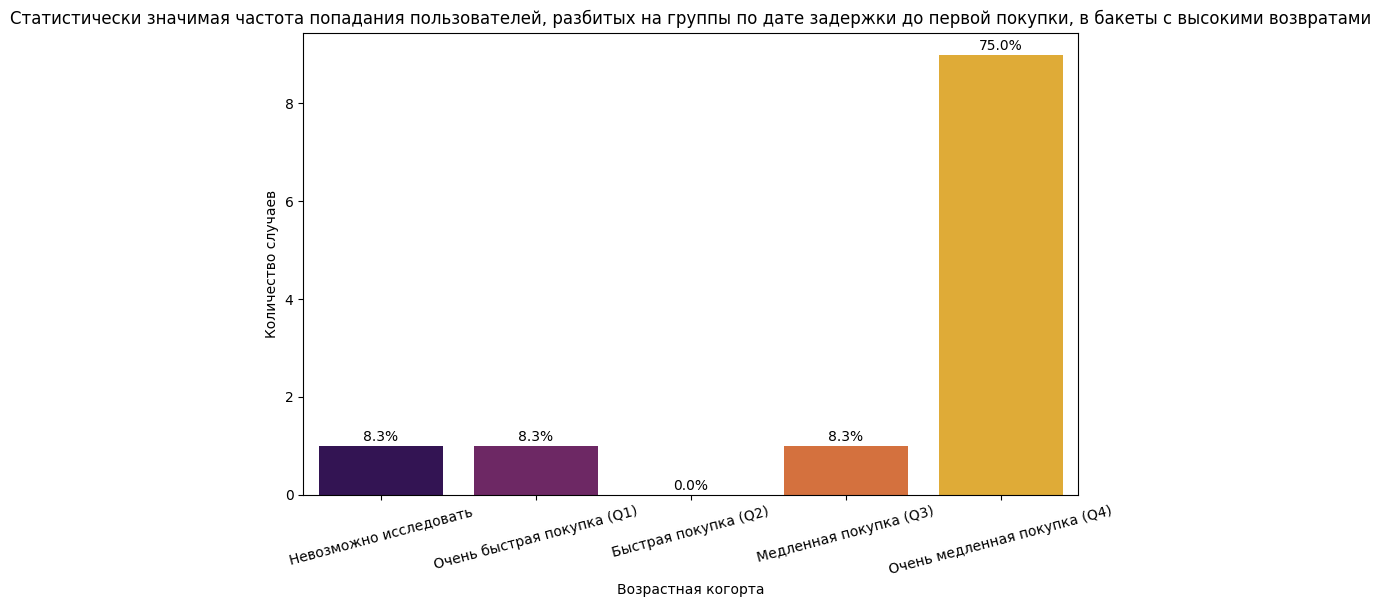

In [36]:
print("=== Z-тест по частоте попадания пользователей разбитых на группы по дате задержки до первой покупки в бакеты с повышенными историческими возвратами ===")

df_z_test_delay = df_h8.copy()

bucket_order = [
    "10–50%",
    "50–100%",
    "100–500%",
    ">500%"
]
cohort_order = [
    "Невозможно исследовать",
    "Очень быстрая покупка (Q1)",
    "Быстрая покупка (Q2)",
    "Медленная покупка (Q3)",
    "Очень медленная покупка (Q4)"
]
results = []

# Проводим z-test для всех проблемных корзин возвратов для каждой возможной пары когорт задержек
for bucket in bucket_order:
    df_z_test_delay[f'in_bucket_{bucket}'] = (df_z_test_delay['hist_return_bucket'] == bucket).astype(int)
    pairs = list(itertools.combinations(cohort_order, 2))
    p_values = []
    pair_list = []
    counts_dict = {}
    
    for c1, c2 in pairs:
        subset = df_z_test_delay[df_z_test_delay['delay_days_cohort'].isin([c1, c2])]
        counts = subset.groupby('delay_days_cohort')[f'in_bucket_{bucket}'].sum()
        nobs = subset.groupby('delay_days_cohort')[f'in_bucket_{bucket}'].count()
        
        proportion_c1 = counts[c1] / nobs[c1]
        proportion_c2 = counts[c2] / nobs[c2]
        counts_dict[(c1, c2)] = (proportion_c1, proportion_c2)
        
        stat, pval = proportions_ztest(counts.values, nobs.values)
        p_values.append(pval)
        pair_list.append((c1, c2))
    # Добавляем поправку, чтобы контролировать рост ошибок первого рода
    reject, pvals_corrected, _, _ = multipletests(p_values, method='bonferroni')
    # Определяем какая когорта попадает в бакет чаще
    for (c1, c2), p_corr, r in zip(pair_list, pvals_corrected, reject):
        prop1, prop2 = counts_dict[(c1, c2)]
        if prop1 > prop2:
            more_freq = c1
        elif prop2 > prop1:
            more_freq = c2
        else:
            more_freq = "равны"
        
        results.append({
            'Корзина': bucket,
            'Когорта 1': c1,
            'Когорта 2': c2,
            'Доля Когорта 1': round(prop1*100, 2),
            'Доля Когорта 2': round(prop2*100, 2),
            'p-value (скорректированное)': round(p_corr, 4),
            'Статистически значимо?': 'Да' if r else 'Нет',
            'Чаще попадает в бакет': more_freq
        })

results_df = pd.DataFrame(results)
pd.set_option('display.max_rows', None)
def highlight_significant(row):
    if row["Статистически значимо?"] == "Да":
        return ["background-color: #D9EDF7"] * len(row)
    else:
        return [""] * len(row)

styled_df = results_df.style.apply(highlight_significant, axis=1)
display(styled_df)

# Построение графика статистически значиных попаданий в проблемную корзину по когортам
sig_df = results_df[results_df["Статистически значимо?"] == "Да"]
freq_df = sig_df['Чаще попадает в бакет'].value_counts().reindex(cohort_order, fill_value=0)
freq_df = freq_df.reset_index()
freq_df.columns = ['Когорта', 'Частота']

total = freq_df['Частота'].sum()
freq_df['Процент'] = freq_df['Частота'] / total * 100

plt.figure(figsize=(10,6))
ax = sns.barplot(
    x='Когорта',
    y='Частота',
    hue='Когорта',
    data=freq_df,
    palette='inferno',
    legend=False)

for i, row in freq_df.iterrows():
    ax.text(i, row['Частота'] + 0.1, f"{row['Процент']:.1f}%", ha='center')

ax.set_title('Статистически значимая частота попадания пользователей, разбитых на группы по дате задержки до первой покупки, в бакеты с высокими возвратами')
ax.set_ylabel('Количество случаев')
ax.set_xlabel('Возрастная когорта')
plt.xticks(rotation=15)
plt.show()

## Выводы
Когорта Q4 статистически чаще возвращает товары и является потенциально проблемной группой, что подтверждается z-тестом.